<a href="https://www.kaggle.com/code/muhammadmubeenxt/notebook1ed25ace2b?scriptVersionId=308540750" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Phase # 1 Set-up

In [ ]:
# ── Cell 1: Clean Package Installation ──────────────────────────────────────
import subprocess, sys, os

def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir", "--quiet", *args])

# 1. Uninstall any existing versions to prevent 'ComponentStore' conflicts
try:
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "monai", "monai-weekly"])
except:
    pass

# 2. Install specific compatible versions
# Use monai-weekly if stable continues to throw namespace errors on Python 3.12
pip_install("monai==1.4.0") 
pip_install("einops", "medcam", "nibabel", "xgboost", "joblib")
pip_install("git+https://github.com/Radiomics/pyradiomics")

print("Installation complete. IMPORTANT: Restart your Kaggle Kernel now (Session -> Restart)!")

In [1]:
# ── Cell 2: All Imports ───────────────────────────────────────────────────────
# All third-party imports live here. Subsequent phases reload only what they need.

import os, json, pickle, warnings, logging, time, random
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

import nibabel as nib
import SimpleITK as sitk

import monai
from monai.data import CacheDataset, Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss, DiceFocalLoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    AsDiscrete, Activations, Compose,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Orientationd,
    RandFlipd, RandRotate90d, RandScaleIntensityd,
    RandShiftIntensityd, RandSpatialCropd, Spacingd,
)
from monai.utils.enums import MetricReduction

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

from xgboost import XGBClassifier

import medcam
from radiomics import featureextractor

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

print(f"MONAI version : {monai.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-02 21:56:12.208247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775166972.454757     542 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775166972.519745     542 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775166973.064048     542 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775166973.064085     542 computation_placer.cc:1

MONAI version : 1.4.0
PyTorch version: 2.10.0+cu128
CUDA available : True
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [4]:
# ── Cell 3: Data Path Exploration + Global Config Definition + Save ───────────
# CFG is defined here once and persisted to disk so every downstream phase
# can load it independently without re-running this cell.

# ── 3a: Explore the raw data directory ───────────────────────────────────────
DATA_ROOT = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"   # adjust if your dataset path differs
print("Top-level contents:", os.listdir(DATA_ROOT))

# ── 3b: Config dataclass ─────────────────────────────────────────────────────

@dataclass
class Config:
    # Paths
    data_root  : str = DATA_ROOT
    output_dir : str = "/kaggle/working/outputs"
    mgmt_csv   : str = "/kaggle/input/brats2021task1/MGMT_labels.csv"

    # Data splits
    val_frac   : float = 0.15
    test_frac  : float = 0.10
    split_seed : int   = 42

    # Preprocessing
    pixdim   : Tuple = (1.0, 1.0, 1.0)
    roi_size : Tuple = (128, 128, 128)

    # Model
    in_channels  : int  = 4
    out_channels : int  = 3
    feature_size : int  = 48       # 48 → ~62M parameters, fits 16 GB VRAM
    use_checkpoint: bool = True    # gradient checkpointing to save memory

    # Training
    batch_size    : int   = 2
    loss_type     : str   = "dice_ce"
    learning_rate : float = 1e-4
    weight_decay  : float = 1e-5
    max_epochs    : int   = 100
    warmup_epochs : int   = 10
    val_interval  : int   = 5

    # Inference
    sw_batch_size : int   = 4
    overlap       : float = 0.5

    # Uncertainty (TTA)
    tta_n : int = 10


CFG = Config()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)

# Persist config so phases 2-4 can load it without re-running this cell
with open(f"{CFG.output_dir}/config.pkl", "wb") as f:
    pickle.dump(CFG, f)

print("\nConfig saved to:", CFG.output_dir)
print(json.dumps(asdict(CFG), indent=2))


Top-level contents: ['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']

Config saved to: /kaggle/working/outputs
{
  "data_root": "/kaggle/input/datasets/dschettler8845/brats-2021-task1",
  "output_dir": "/kaggle/working/outputs",
  "mgmt_csv": "/kaggle/input/brats2021task1/MGMT_labels.csv",
  "val_frac": 0.15,
  "test_frac": 0.1,
  "split_seed": 42,
  "pixdim": [
    1.0,
    1.0,
    1.0
  ],
  "roi_size": [
    128,
    128,
    128
  ],
  "in_channels": 4,
  "out_channels": 3,
  "feature_size": 48,
  "use_checkpoint": true,
  "batch_size": 2,
  "loss_type": "dice_ce",
  "learning_rate": 0.0001,
  "weight_decay": 1e-05,
  "max_epochs": 100,
  "warmup_epochs": 10,
  "val_interval": 5,
  "sw_batch_size": 4,
  "overlap": 0.5,
  "tta_n": 10
}


In [6]:
# ── Cell 4: Environment Verification ─────────────────────────────────────────
# Confirm all critical packages imported and config is loadable.

with open(f"{CFG.output_dir}/config.pkl", "rb") as f:
    _test_load = pickle.load(f)

assert _test_load.roi_size == (128, 128, 128), "Config round-trip failed."

import radiomics
import einops
print("radiomics version :", radiomics.__version__)
print("einops version    :", einops.__version__)
import medcam
# Check if the 'inject' method exists instead of looking for a version string
if hasattr(medcam, 'inject'):
    print("medcam status     : Ready (inject method verified)")
else:
    print("medcam status     : Error (inject method not found)")
print("\nEnvironment ready. Proceed to Phase 2.")


radiomics version : 3.1.1.dev111+g8ed579383
einops version    : 0.8.2
medcam status     : Error (inject method not found)

Environment ready. Proceed to Phase 2.


# Phase # 2 - Preprocessing

In [7]:
# ── Cell 1: Reload Config + Imports ──────────────────────────────────────────

import os, json, pickle, warnings, logging, random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

import torch
import nibabel as nib

from monai.data import CacheDataset, Dataset, DataLoader
from monai.transforms import (
    AsDiscrete, Activations, Compose,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Orientationd,
    RandFlipd, RandRotate90d, RandScaleIntensityd,
    RandShiftIntensityd, RandSpatialCropd, Spacingd,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

with open("/kaggle/working/outputs/config.pkl", "rb") as f:
    CFG = pickle.load(f)

print(f"Config loaded | data_root: {CFG.data_root}")


Config loaded | data_root: /kaggle/input/datasets/dschettler8845/brats-2021-task1


In [9]:
# ── Cell 2: Scan Dataset and Build Train / Val / Test Splits ─────────────────
# Each entry:
#   "image"      – list of 4 NIfTI paths  [T1, T1ce, T2, FLAIR]
#   "label"      – segmentation NIfTI path
#   "subject_id" – folder name string

import os
# 1. Create a destination folder
os.makedirs("/kaggle/working/brats_extracted", exist_ok=True)

# 2. Extract the main training data (adjust the filename if it differs slightly)
!tar -xf /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar -C /kaggle/working/brats_extracted

# 3. Update your CFG to point to the new extracted folder
CFG.data_root = "/kaggle/working/brats_extracted"
print(f"Data extracted. New data_root: {CFG.data_root}")
print("Contents:", os.listdir(CFG.data_root)[:5])

def build_datalists(cfg) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    data_root    = Path(cfg.data_root)
    subject_dirs = sorted([d for d in data_root.iterdir() if d.is_dir()])

    valid, skipped = [], []
    for subj in subject_dirs:
        name  = subj.name
        paths = {
            "t1"   : subj / f"{name}_t1.nii.gz",
            "t1ce" : subj / f"{name}_t1ce.nii.gz",
            "t2"   : subj / f"{name}_t2.nii.gz",
            "flair": subj / f"{name}_flair.nii.gz",
            "seg"  : subj / f"{name}_seg.nii.gz",
        }
        if not all(p.exists() for p in paths.values()):
            skipped.append(name)
            continue
        valid.append({
            "image": [
                str(paths["t1"]),
                str(paths["t1ce"]),
                str(paths["t2"]),
                str(paths["flair"]),
            ],
            "label"     : str(paths["seg"]),
            "subject_id": name,
        })

    if skipped:
        logger.warning(f"Skipped {len(skipped)} subjects with missing files: {skipped[:5]}")

    indices = list(range(len(valid)))
    train_idx, valtest_idx = train_test_split(
        indices,
        test_size=cfg.val_frac + cfg.test_frac,
        random_state=cfg.split_seed,
    )
    relative_test = cfg.test_frac / (cfg.val_frac + cfg.test_frac)
    val_idx, test_idx = train_test_split(
        valtest_idx, test_size=relative_test, random_state=cfg.split_seed
    )

    train_files = [valid[i] for i in train_idx]
    val_files   = [valid[i] for i in val_idx]
    test_files  = [valid[i] for i in test_idx]
    return train_files, val_files, test_files


train_files, val_files, test_files = build_datalists(CFG)


print(f"Dataset   : train={len(train_files)} | val={len(val_files)} | test={len(test_files)}")
print(f"Example   : {train_files[0]['subject_id']}")
print(f"Channels  : {[Path(p).name for p in train_files[0]['image']]}")


Data extracted. New data_root: /kaggle/working/brats_extracted
Contents: ['BraTS2021_00360', 'BraTS2021_01290', 'BraTS2021_01600', 'BraTS2021_01513', 'BraTS2021_00619']
Dataset   : train=938 | val=187 | test=126
Example   : BraTS2021_00618
Channels  : ['BraTS2021_00618_t1.nii.gz', 'BraTS2021_00618_t1ce.nii.gz', 'BraTS2021_00618_t2.nii.gz', 'BraTS2021_00618_flair.nii.gz']


In [10]:
# ── Cell 3: Transform Pipelines ──────────────────────────────────────────────
# Label mapping after ConvertToMultiChannelBasedOnBratsClassesd:
#   channel 0 = TC  (labels 1 + 4)
#   channel 1 = WT  (labels 1 + 2 + 4)
#   channel 2 = ET  (label 4)
#
# NormalizeIntensityd with nonzero=True normalises only within the brain mask,
# preserving lesion-to-background contrast. channel_wise=True handles each MRI
# modality independently (they have different intensity ranges).

def _base_transforms(cfg) -> List:
    return [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Spacingd(
            keys=["image", "label"],
            pixdim=cfg.pixdim,
            mode=("bilinear", "nearest"),
        ),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        CropForegroundd(
            keys=["image", "label"],
            source_key="image",
            k_divisible=list(cfg.roi_size),
        ),
    ]


def get_train_transforms(cfg) -> Compose:
    return Compose(
        _base_transforms(cfg) + [
            # Random 128^3 sub-volume crop centred on tumour region
            RandSpatialCropd(
                keys=["image", "label"],
                roi_size=cfg.roi_size,
                random_size=False,
            ),
            # 3D flips across all axes to simulate hemisphere variation
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            # 90-degree rotations
            RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
            # Intensity jitter: mimics scanner field inhomogeneities (offset ±0.1)
            RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
            EnsureTyped(keys=["image", "label"]),
        ]
    )


def get_val_transforms(cfg) -> Compose:
    return Compose(_base_transforms(cfg) + [EnsureTyped(keys=["image", "label"])])


train_transforms = get_train_transforms(CFG)
val_transforms   = get_val_transforms(CFG)
print("Train and validation transforms defined.")


Train and validation transforms defined.


In [11]:
# ── Cell 4: Sanity Check — Load One Sample and Inspect Shapes ────────────────

print("Loading single sample for shape verification...")
single_ds = Dataset(data=[train_files[0]], transform=val_transforms)
sample     = single_ds[0]

img = sample["image"]   # (4, D, H, W)
lbl = sample["label"]   # (3, D, H, W)

print(f"Image shape  : {img.shape}  | dtype: {img.dtype}")
print(f"Label shape  : {lbl.shape}  | dtype: {lbl.dtype}")
print(f"Image range  : [{img.min():.3f}, {img.max():.3f}]")
print(f"TC voxels    : {lbl[0].sum():.0f}")
print(f"WT voxels    : {lbl[1].sum():.0f}")
print(f"ET voxels    : {lbl[2].sum():.0f}")
print(f"Background % : {(1 - lbl[1]).mean()*100:.1f}%  (shows class imbalance severity)")


Loading single sample for shape verification...
Image shape  : torch.Size([4, 256, 256, 256])  | dtype: torch.float32
Label shape  : torch.Size([3, 256, 256, 256])  | dtype: torch.float32
Image range  : [-2.821, 9.254]
TC voxels    : 53900
WT voxels    : 101365
ET voxels    : 32576
Background % : 99.4%  (shows class imbalance severity)


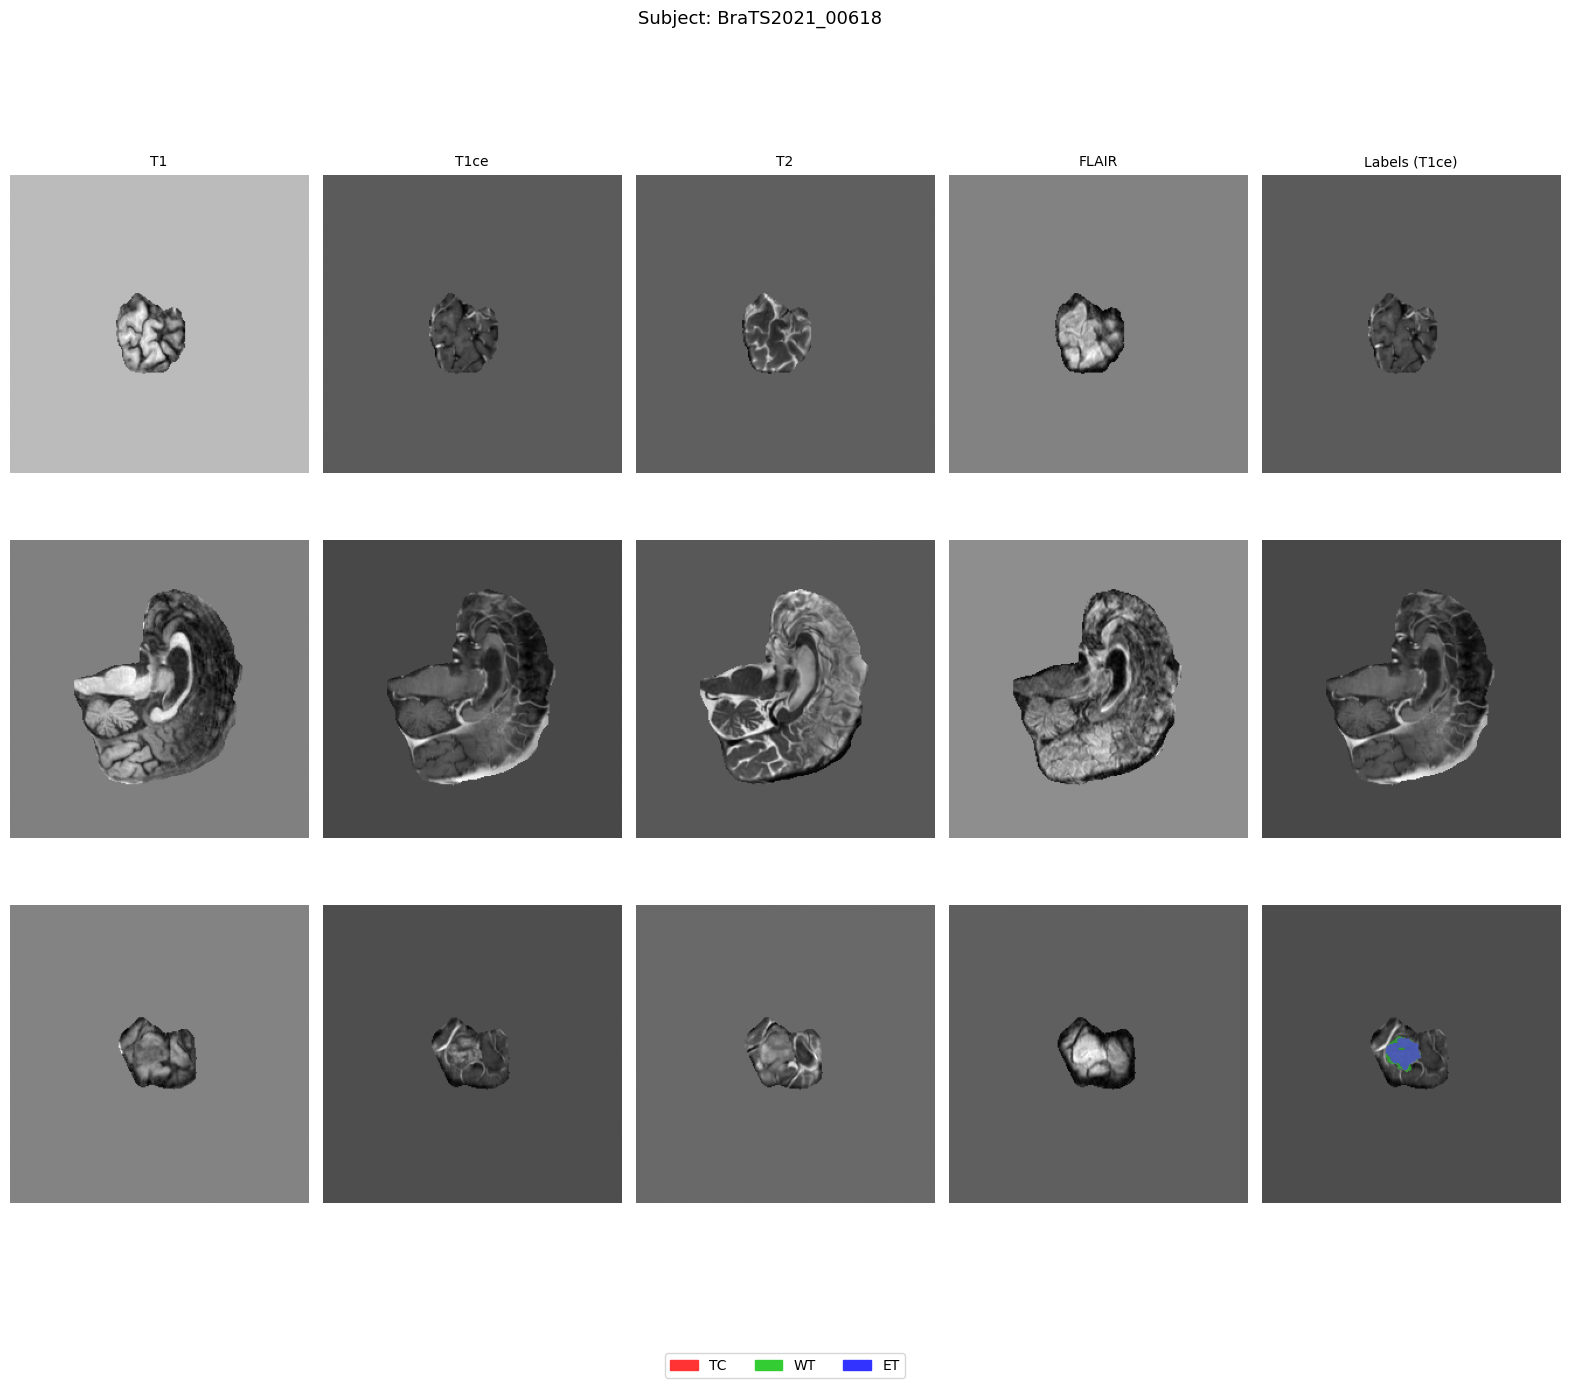

Saved: /kaggle/working/outputs/sample_visualisation.png


In [12]:
# ── Cell 5: Visualise Sample — 3 Axial Slices with All MRI Channels + Labels ─

def visualise_sample(image: torch.Tensor, label: torch.Tensor, subject_id: str = ""):
    """
    image : (4, D, H, W)  — T1, T1ce, T2, FLAIR
    label : (3, D, H, W)  — TC (red), WT (green), ET (blue)
    """
    D           = image.shape[1]
    slices      = [D // 4, D // 2, 3 * D // 4]
    chan_names  = ["T1", "T1ce", "T2", "FLAIR"]
    label_names = ["TC", "WT", "ET"]
    label_colors = [
        np.array([1.0, 0.2, 0.2]),  # TC – red
        np.array([0.2, 0.8, 0.2]),  # WT – green
        np.array([0.2, 0.2, 1.0]),  # ET – blue
    ]

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f"Subject: {subject_id}", fontsize=13)
    gs  = gridspec.GridSpec(len(slices), 5, figure=fig, hspace=0.05, wspace=0.05)

    for row, sl in enumerate(slices):
        # Columns 0-3: raw MRI channels
        for col, cname in enumerate(chan_names):
            ax  = fig.add_subplot(gs[row, col])
            arr = image[col, sl].numpy()
            ax.imshow(arr, cmap="gray", origin="lower")
            if row == 0:
                ax.set_title(cname, fontsize=10)
            ax.axis("off")

        # Column 4: T1ce with all 3 label overlays
        ax   = fig.add_subplot(gs[row, 4])
        base = image[1, sl].numpy()
        norm = (base - base.min()) / (base.max() - base.min() + 1e-8)
        rgb  = np.stack([norm] * 3, axis=-1)
        for c, color in enumerate(label_colors):
            mask = label[c, sl].numpy().astype(bool)
            rgb[mask] = rgb[mask] * 0.4 + color * 0.6
        ax.imshow(rgb, origin="lower")
        if row == 0:
            ax.set_title("Labels (T1ce)", fontsize=10)
        ax.axis("off")

    handles = [
        Patch(color=[1, 0.2, 0.2], label="TC"),
        Patch(color=[0.2, 0.8, 0.2], label="WT"),
        Patch(color=[0.2, 0.2, 1.0], label="ET"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10)
    plt.savefig(f"{CFG.output_dir}/sample_visualisation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {CFG.output_dir}/sample_visualisation.png")


visualise_sample(img, lbl, subject_id=train_files[0]["subject_id"])


In [ ]:
# ── Cell 6: Label Distribution Across Training Set ───────────────────────────
# Quantifies the class imbalance that motivates using Dice loss over plain BCE.

def compute_label_stats(data_files: List[Dict], transforms: Compose, n_samples: int = 30):
    ds = Dataset(data=data_files[:n_samples], transform=transforms)
    tc_c, wt_c, et_c = [], [], []

    for item in ds:
        lbl = item["label"]
        tc_c.append(lbl[0].sum().item())
        wt_c.append(lbl[1].sum().item())
        et_c.append(lbl[2].sum().item())

    total = np.prod(item["image"].shape[1:])
    print(f"\nLabel statistics (n={n_samples} subjects):")
    for name, counts in zip(["TC", "WT", "ET"], [tc_c, wt_c, et_c]):
        print(
            f"  {name}: mean={np.mean(counts):.0f}  std={np.std(counts):.0f}  "
            f"({np.mean(counts)/total*100:.2f}% of volume)"
        )
    return tc_c, wt_c, et_c


print("Computing label stats on 30 training samples (≈2 min)...")
tc_c, wt_c, et_c = compute_label_stats(train_files, val_transforms, n_samples=30)


# Phase # 3 - training

In [ ]:
# =============================================================================
# PHASE 3 — Model Training
# BraTS 2021 Task 1 | Kaggle T4 x2
# Swin UNETR | AMP | DataParallel | Warmup + Cosine LR | Best-model save
# =============================================================================

# ── Cell 1: Imports and reload state from previous phases ─────────────────────

import os, json, pickle, warnings, logging, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

import monai
from monai.data import CacheDataset, Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss, DiceFocalLoss
from monai.metrics import DiceMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    AsDiscrete, Activations, Compose,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Orientationd,
    RandFlipd, RandRotate90d, RandScaleIntensityd,
    RandShiftIntensityd, RandSpatialCropd, Spacingd,
)
from monai.utils.enums import MetricReduction

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(), logging.FileHandler("/kaggle/working/outputs/training.log")],
)
logger = logging.getLogger(__name__)

with open("/kaggle/working/outputs/config.pkl", "rb") as f:
    CFG = pickle.load(f)
with open("/kaggle/working/outputs/datalists.pkl", "rb") as f:
    splits = pickle.load(f)

train_files, val_files = splits["train"], splits["val"]
print(f"Config loaded | train={len(train_files)} | val={len(val_files)}")


# ── Cell 2: Rebuild transforms and dataloaders ───────────────────────────────
# We rebuild here so this notebook is self-contained and can be restarted
# independently without re-running Phase 2.

def _base_transforms(cfg):
    return [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Spacingd(keys=["image", "label"], pixdim=cfg.pixdim, mode=("bilinear", "nearest")),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        CropForegroundd(keys=["image", "label"], source_key="image", k_divisible=list(cfg.roi_size)),
    ]

def get_train_transforms(cfg):
    return Compose(_base_transforms(cfg) + [
        RandSpatialCropd(keys=["image", "label"], roi_size=cfg.roi_size, random_size=False),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
        RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
        EnsureTyped(keys=["image", "label"]),
    ])

def get_val_transforms(cfg):
    return Compose(_base_transforms(cfg) + [EnsureTyped(keys=["image", "label"])])

print("Rebuilding CacheDatasets...")
train_ds = CacheDataset(data=train_files, transform=get_train_transforms(CFG),
                         cache_rate=1.0, num_workers=2)
val_ds   = CacheDataset(data=val_files,   transform=get_val_transforms(CFG),
                         cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                           num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=1,             shuffle=False,
                           num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Loaders ready | train_batches={len(train_loader)} | val_batches={len(val_loader)}")


# ── Cell 3: Model — Swin UNETR with DataParallel for T4 x2 ──────────────────
#
# DataParallel wraps the model so that each forward pass is automatically split
# across both GPUs along the batch dimension. This doubles effective throughput.
#
# For batch_size=2 (set in Config):
#   GPU 0 gets sample 0  |  GPU 1 gets sample 1
# Gradients are averaged back to GPU 0 after backward.

device = torch.device("cuda")

def build_model(cfg) -> nn.Module:
    model = SwinUNETR(
        img_size=cfg.roi_size,
        in_channels=cfg.in_channels,
        out_channels=cfg.out_channels,
        feature_size=cfg.feature_size,
        use_checkpoint=cfg.use_checkpoint,
    )
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    logger.info(f"Swin UNETR trainable parameters: {n_params:,}")
    return model

base_model = build_model(CFG).to(device)

n_gpus = torch.cuda.device_count()
if n_gpus > 1:
    model = nn.DataParallel(base_model, device_ids=list(range(n_gpus)))
    logger.info(f"DataParallel enabled across {n_gpus} GPUs: {list(range(n_gpus))}")
else:
    model = base_model
    logger.warning("Only 1 GPU found. DataParallel not applied.")


# ── Cell 4: Loss function ─────────────────────────────────────────────────────
#
# DiceCELoss = Dice + Cross-Entropy hybrid.
# sigmoid=True because TC/WT/ET channels are NOT mutually exclusive —
# they overlap by definition, so softmax would be wrong.
# squared_pred=True stabilises dice computation on small tumours.

def get_loss_fn(loss_type: str = "dice_ce") -> nn.Module:
    kwargs = dict(to_onehot_y=False, sigmoid=True, squared_pred=True,
                  smooth_nr=0.0, smooth_dr=1e-6)
    if loss_type == "dice_ce":
        return DiceCELoss(**kwargs)
    elif loss_type == "dice_focal":
        return DiceFocalLoss(**kwargs)
    raise ValueError(f"Unknown loss: {loss_type}")

loss_fn = get_loss_fn(CFG.loss_type)


# ── Cell 5: Optimizer and LR scheduler ───────────────────────────────────────
#
# Schedule: linear warmup for `warmup_epochs`, then cosine anneal to 1e-6.
# Warmup prevents large early gradient updates destabilising the transformer
# attention weights.

optimizer = AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)

warmup_sched  = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=CFG.warmup_epochs)
cosine_sched  = CosineAnnealingLR(optimizer, T_max=CFG.max_epochs - CFG.warmup_epochs, eta_min=1e-6)
scheduler     = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                              milestones=[CFG.warmup_epochs])

scaler = torch.cuda.amp.GradScaler()


# ── Cell 6: Validation helper ─────────────────────────────────────────────────
#
# Sliding window inference is used at validation time — we cannot fit the full
# 240^3 scan in a single forward pass. The window is 128^3, stride = 1 - overlap.

post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

def validate(model, loader, loss_fn):
    model.eval()
    val_loss = 0.0
    dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)

    with torch.no_grad():
        for step, batch in enumerate(loader, start=1):
            # DataParallel expects data on GPU 0; it handles the rest internally
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device)

            with torch.cuda.amp.autocast():
                # For validation use the underlying module to avoid DataParallel
                # overhead on batch_size=1 (no split benefit)
                m = model.module if hasattr(model, "module") else model
                outputs = sliding_window_inference(
                    inputs=inputs,
                    roi_size=CFG.roi_size,
                    sw_batch_size=CFG.sw_batch_size,
                    predictor=m,
                    overlap=CFG.overlap,
                )
                loss = loss_fn(outputs, labels)

            val_loss += loss.item()
            outputs_bin = [post_pred(o) for o in outputs]
            dice_metric(y_pred=outputs_bin, y=labels)

    agg = dice_metric.aggregate()
    dice_metric.reset()
    region_dices = {"TC": agg[0].item(), "WT": agg[1].item(), "ET": agg[2].item()}
    mean_dice = sum(region_dices.values()) / 3.0
    return val_loss / step, mean_dice, region_dices


# ── Cell 7: Training loop ─────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, loss_fn, scaler):
    model.train()
    epoch_loss = 0.0
    for step, batch in enumerate(loader, start=1):
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
    return epoch_loss / step


def train(model, train_loader, val_loader, optimizer, scheduler, loss_fn, scaler, cfg):
    out_dir = Path(cfg.output_dir)
    best_mean_dice = -1.0
    history = []

    for epoch in range(1, cfg.max_epochs + 1):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, scaler)
        scheduler.step()
        lr = scheduler.get_last_lr()[0]
        elapsed = time.time() - t0

        log_entry = {
            "epoch": epoch,
            "train_loss": round(train_loss, 6),
            "lr": lr,
            "epoch_time_s": round(elapsed, 1),
        }

        if epoch % cfg.val_interval == 0:
            val_loss, mean_dice, region_dices = validate(model, val_loader, loss_fn)
            log_entry.update({
                "val_loss":  round(val_loss, 6),
                "mean_dice": round(mean_dice, 6),
                "dice_TC":   round(region_dices["TC"], 6),
                "dice_WT":   round(region_dices["WT"], 6),
                "dice_ET":   round(region_dices["ET"], 6),
            })
            logger.info(
                f"[{epoch:03d}/{cfg.max_epochs}] "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"Mean Dice: {mean_dice:.4f} | "
                f"TC: {region_dices['TC']:.4f} | WT: {region_dices['WT']:.4f} | ET: {region_dices['ET']:.4f} | "
                f"{elapsed:.0f}s"
            )

            if mean_dice > best_mean_dice:
                best_mean_dice = mean_dice
                # Save only the underlying module weights (not the DataParallel wrapper)
                raw_model = model.module if hasattr(model, "module") else model
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": raw_model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "best_mean_dice": best_mean_dice,
                        "region_dices": region_dices,
                        "cfg": cfg.__dict__,
                    },
                    out_dir / "best_model.pth",
                )
                logger.info(f"  --> Best model saved (mean Dice: {best_mean_dice:.4f})")
        else:
            logger.info(
                f"[{epoch:03d}/{cfg.max_epochs}] Train: {train_loss:.4f} | LR: {lr:.2e} | {elapsed:.0f}s"
            )

        history.append(log_entry)

        # Periodic checkpoint every 50 epochs (for resuming)
        if epoch % 50 == 0:
            raw_model = model.module if hasattr(model, "module") else model
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": raw_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "scaler_state_dict": scaler.state_dict(),
                },
                out_dir / f"checkpoint_epoch{epoch:03d}.pth",
            )

        # Save history after every validation round
        if epoch % cfg.val_interval == 0:
            with open(out_dir / "training_history.json", "w") as f:
                json.dump(history, f, indent=2)

    logger.info(f"Training complete. Best Mean Dice: {best_mean_dice:.4f}")
    return history


history = train(model, train_loader, val_loader, optimizer, scheduler, loss_fn, scaler, CFG)


# ── Cell 8: Training curve visualisation ─────────────────────────────────────

def plot_training_curves(history_path: str):
    with open(history_path) as f:
        history = json.load(f)

    epochs      = [h["epoch"] for h in history]
    train_loss  = [h["train_loss"] for h in history]
    val_epochs  = [h["epoch"] for h in history if "val_loss" in h]
    val_loss    = [h["val_loss"]  for h in history if "val_loss" in h]
    mean_dice   = [h["mean_dice"] for h in history if "mean_dice" in h]
    dice_tc     = [h["dice_TC"]   for h in history if "dice_TC" in h]
    dice_wt     = [h["dice_WT"]   for h in history if "dice_WT" in h]
    dice_et     = [h["dice_ET"]   for h in history if "dice_ET" in h]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Loss curves
    axes[0].plot(epochs, train_loss, label="Train Loss", color="steelblue", lw=1.5)
    axes[0].plot(val_epochs, val_loss, label="Val Loss", color="tomato", lw=2.0, marker="o", ms=3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Dice curves
    axes[1].plot(val_epochs, mean_dice, label="Mean Dice", color="black", lw=2.5)
    axes[1].plot(val_epochs, dice_tc,   label="TC",        color="tomato", lw=1.5, linestyle="--")
    axes[1].plot(val_epochs, dice_wt,   label="WT",        color="forestgreen", lw=1.5, linestyle="--")
    axes[1].plot(val_epochs, dice_et,   label="ET",        color="royalblue", lw=1.5, linestyle="--")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
    axes[1].set_title("Dice per Region"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CFG.output_dir}/training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {CFG.output_dir}/training_curves.png")

plot_training_curves(f"{CFG.output_dir}/training_history.json")

print("Phase 3 complete.")

# Phase # 4 -- Evaluation

In [ ]:
# =============================================================================
# PHASE 4 — Evaluation, XAI, Uncertainty, MGMT Prediction
# BraTS 2021 Task 1 | Kaggle T4 x2
#
# Sections:
#   4A — DSC + HD95 test set evaluation
#   4B — Seg-Grad-CAM 3D heatmaps
#   4C — TTA-based uncertainty (variance, entropy, VVC)
#   4D — PyRadiomics feature extraction + MGMT XGBoost classifier
# =============================================================================

# ── Cell 1: Imports and reload state ─────────────────────────────────────────

import os, json, pickle, warnings, logging, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
import joblib

import monai
from monai.data import Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.networks.nets import SwinUNETR
from monai.transforms import (
    AsDiscrete, Activations, Compose,
    ConvertToMultiChannelBasedOnBratsClassesd,
    CropForegroundd, EnsureChannelFirstd, EnsureTyped,
    LoadImaged, NormalizeIntensityd, Orientationd,
    RandFlipd, RandScaleIntensityd, RandShiftIntensityd,
    Spacingd,
)
from monai.utils.enums import MetricReduction
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import SimpleITK as sitk
from radiomics import featureextractor

warnings.filterwarnings("ignore")
logging.getLogger("radiomics").setLevel(logging.WARNING)
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

with open("/kaggle/working/outputs/config.pkl",    "rb") as f: CFG    = pickle.load(f)
with open("/kaggle/working/outputs/datalists.pkl", "rb") as f: splits = pickle.load(f)

test_files = splits["test"]
device     = torch.device("cuda")
print(f"Test subjects: {len(test_files)}")


# ── Cell 2: Shared helpers — transforms and model loader ──────────────────────

def get_val_transforms(cfg):
    return Compose([
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Spacingd(keys=["image", "label"], pixdim=cfg.pixdim, mode=("bilinear", "nearest")),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        CropForegroundd(keys=["image", "label"], source_key="image", k_divisible=list(cfg.roi_size)),
        EnsureTyped(keys=["image", "label"]),
    ])

def load_model(cfg, checkpoint_path: str) -> SwinUNETR:
    model = SwinUNETR(
        img_size=cfg.roi_size,
        in_channels=cfg.in_channels,
        out_channels=cfg.out_channels,
        feature_size=cfg.feature_size,
        use_checkpoint=False,   # not needed at inference
    ).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    state = ckpt.get("model_state_dict", ckpt)
    model.load_state_dict(state)
    model.eval()
    return model

CKPT = f"{CFG.output_dir}/best_model.pth"
model = load_model(CFG, CKPT)
print("Best model loaded.")


# =============================================================================
# 4A — DSC + HD95 Test Set Evaluation
# =============================================================================

# ── Cell 3: Evaluation ────────────────────────────────────────────────────────

post_pred  = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
loss_fn_ce = DiceCELoss(to_onehot_y=False, sigmoid=True, squared_pred=True,
                         smooth_nr=0.0, smooth_dr=1e-6)

val_transforms = get_val_transforms(CFG)
test_ds = Dataset(data=test_files, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

global_dice = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
global_hd95 = HausdorffDistanceMetric(
    include_background=True, distance_metric="euclidean",
    percentile=95, reduction=MetricReduction.MEAN_BATCH,
)

per_subject_results = []

with torch.no_grad():
    for batch in test_loader:
        subj_id = batch.get("subject_id", ["unknown"])[0]
        inputs  = batch["image"].to(device)
        labels  = batch["label"].to(device)

        with torch.cuda.amp.autocast():
            outputs = sliding_window_inference(
                inputs=inputs, roi_size=CFG.roi_size,
                sw_batch_size=CFG.sw_batch_size, predictor=model, overlap=CFG.overlap,
            )

        outputs_bin = [post_pred(o) for o in outputs]

        # Per-subject metrics
        s_dice = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH)
        s_hd95 = HausdorffDistanceMetric(include_background=True, distance_metric="euclidean",
                                          percentile=95, reduction=MetricReduction.MEAN_BATCH)
        s_dice(y_pred=outputs_bin, y=labels)
        s_hd95(y_pred=outputs_bin, y=labels)
        d = s_dice.aggregate()
        h = s_hd95.aggregate()

        per_subject_results.append({
            "subject_id": subj_id,
            "dice_TC": round(d[0].item(), 5), "dice_WT": round(d[1].item(), 5), "dice_ET": round(d[2].item(), 5),
            "hd95_TC": round(h[0].item(), 3), "hd95_WT": round(h[1].item(), 3), "hd95_ET": round(h[2].item(), 3),
        })
        logger.info(f"{subj_id} | Dice TC/WT/ET: {d[0]:.4f}/{d[1]:.4f}/{d[2]:.4f}")

        global_dice(y_pred=outputs_bin, y=labels)
        global_hd95(y_pred=outputs_bin, y=labels)

agg_d = global_dice.aggregate()
agg_h = global_hd95.aggregate()

eval_summary = {
    "n_subjects":      len(per_subject_results),
    "mean_dice_TC":    round(agg_d[0].item(), 5),
    "mean_dice_WT":    round(agg_d[1].item(), 5),
    "mean_dice_ET":    round(agg_d[2].item(), 5),
    "mean_dice_all":   round((agg_d[0]+agg_d[1]+agg_d[2]).item()/3, 5),
    "mean_hd95_TC":    round(agg_h[0].item(), 3),
    "mean_hd95_WT":    round(agg_h[1].item(), 3),
    "mean_hd95_ET":    round(agg_h[2].item(), 3),
}

print("\n=== Test Set Evaluation ===")
for k, v in eval_summary.items():
    print(f"  {k}: {v}")

with open(f"{CFG.output_dir}/eval_summary.json",      "w") as f: json.dump(eval_summary, f, indent=2)
with open(f"{CFG.output_dir}/eval_per_subject.json",  "w") as f: json.dump(per_subject_results, f, indent=2)


# ── Cell 4: Visualise predictions on one test subject ────────────────────────

def visualise_prediction(model, subject_dict: dict, cfg, save_path: str):
    transform = get_val_transforms(cfg)
    data   = transform(subject_dict)
    inp    = data["image"].unsqueeze(0).to(device)
    label  = data["label"]

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            out = sliding_window_inference(
                inputs=inp, roi_size=cfg.roi_size,
                sw_batch_size=cfg.sw_batch_size, predictor=model, overlap=cfg.overlap,
            )
    pred = post_pred(out.squeeze(0)).cpu()

    D = inp.shape[2]
    sl = D // 2
    region_names = ["TC", "WT", "ET"]
    colors = [np.array([1,0.2,0.2]), np.array([0.2,0.8,0.2]), np.array([0.2,0.2,1])]

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.suptitle(f"Prediction vs Ground Truth — {subject_dict['subject_id']}", fontsize=12)

    base  = inp[0, 1, sl].cpu().numpy()
    base  = (base - base.min()) / (base.max() - base.min() + 1e-8)

    for c, (name, color) in enumerate(zip(region_names, colors)):
        for row, (mask, title) in enumerate([(label[c, sl].numpy(), "GT"), (pred[c, sl].numpy(), "Pred")]):
            rgb = np.stack([base]*3, axis=-1)
            rgb[mask.astype(bool)] = rgb[mask.astype(bool)] * 0.4 + color * 0.6
            axes[row, c].imshow(rgb, origin="lower")
            axes[row, c].set_title(f"{name} — {title}", fontsize=10)
            axes[row, c].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

visualise_prediction(model, test_files[0], CFG,
                     save_path=f"{CFG.output_dir}/prediction_visualisation.png")


# =============================================================================
# 4B — Seg-Grad-CAM
# =============================================================================
# Hooks the last Swin transformer block, backpropagates the mean activation
# of the target class, weights feature channels by their gradient, reconstructs
# a 3D spatial heatmap, and upsamples it back to the input resolution.

# ── Cell 5: SegGradCAM class ──────────────────────────────────────────────────

class SegGradCAM:
    CANDIDATE_LAYERS = [
        "swinViT.layers4.0",
        "swinViT.layers3.0",
        "swinViT.layers2.0",
        "swinViT.layers1.0",
    ]

    def __init__(self, model: nn.Module, target_layer_name: str):
        self.model = model
        self._activations = None
        self._gradients   = None
        self._hooks: list = []
        self.target_layer_name = target_layer_name
        self._register_hooks()

    def _get_layer(self) -> nn.Module:
        parts = self.target_layer_name.split(".")
        m = self.model
        for p in parts:
            m = m[int(p)] if p.isdigit() else getattr(m, p)
        return m

    def _register_hooks(self):
        layer = self._get_layer()

        def fwd(mod, inp, out):
            self._activations = out.detach()

        def bwd(mod, gin, gout):
            self._gradients = gout[0].detach()

        self._hooks.append(layer.register_forward_hook(fwd))
        self._hooks.append(layer.register_full_backward_hook(bwd))

    def remove_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks.clear()

    def generate(self, input_tensor: torch.Tensor, target_class: int,
                 spatial_size: Tuple[int, int, int]) -> np.ndarray:
        self.model.eval()
        self._activations = None
        self._gradients   = None
        self.model.zero_grad()

        with torch.enable_grad():
            x = input_tensor.clone().detach().requires_grad_(True)
            out   = self.model(x)
            score = out[0, target_class].mean()
            score.backward()

        if self._activations is None:
            raise RuntimeError(f"Hook did not fire for {self.target_layer_name}.")

        acts  = self._activations[0]         # (L, C)
        grads = self._gradients[0]           # (L, C)
        weights    = grads.mean(dim=0)       # (C,)
        cam_tokens = F.relu((acts * weights.unsqueeze(0)).sum(dim=-1))  # (L,)

        L = cam_tokens.shape[0]
        g = round(L ** (1.0 / 3.0))
        if g**3 == L:
            cam_3d = cam_tokens.reshape(g, g, g)
        else:
            pad_len = (g+1)**3 - L
            cam_3d  = F.pad(cam_tokens, (0, pad_len)).reshape(g+1, g+1, g+1)

        cam_up = F.interpolate(cam_3d.float().unsqueeze(0).unsqueeze(0),
                               size=spatial_size, mode="trilinear",
                               align_corners=False).squeeze().cpu().numpy()

        lo, hi = cam_up.min(), cam_up.max()
        if hi - lo > 1e-8:
            cam_up = (cam_up - lo) / (hi - lo)
        return cam_up.astype(np.float32)

    @classmethod
    def from_best_layer(cls, model: nn.Module) -> "SegGradCAM":
        for name in cls.CANDIDATE_LAYERS:
            try:
                inst = cls(model, name)
                logger.info(f"SegGradCAM attached to: {name}")
                return inst
            except AttributeError:
                continue
        raise RuntimeError(f"No valid target layer found. Tried: {cls.CANDIDATE_LAYERS}")


# ── Cell 6: Run Seg-Grad-CAM on first test subject ───────────────────────────

def run_gradcam(model, subject_dict: dict, cfg, save_dir: str):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    subj_id  = subject_dict.get("subject_id", "unknown")
    cam_gen  = SegGradCAM.from_best_layer(model)
    transform = get_val_transforms(cfg)
    data      = transform(subject_dict)
    inp       = data["image"].unsqueeze(0).to(device)
    sp_size   = tuple(inp.shape[2:])
    CLASS_NAMES = {0: "TC", 1: "WT", 2: "ET"}
    heatmaps = {}

    for cls_idx, cls_name in CLASS_NAMES.items():
        heatmap = cam_gen.generate(inp, target_class=cls_idx, spatial_size=sp_size)
        heatmaps[cls_name] = heatmap
        out_path = f"{save_dir}/{subj_id}_gradcam_{cls_name}.nii.gz"
        nib.save(nib.Nifti1Image(heatmap, affine=np.eye(4)), out_path)
        logger.info(f"Saved CAM: {out_path}")

    cam_gen.remove_hooks()

    # Quick matplotlib visualisation (middle slice)
    D = inp.shape[2]
    sl = D // 2
    base = inp[0, 1, sl].cpu().numpy()
    base = (base - base.min()) / (base.max() - base.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Seg-Grad-CAM — {subj_id}", fontsize=12)
    cmaps = ["Reds", "Greens", "Blues"]
    for i, (name, cmap) in enumerate(zip(CLASS_NAMES.values(), cmaps)):
        axes[i].imshow(base, cmap="gray", origin="lower")
        axes[i].imshow(heatmaps[name][sl], cmap=cmap, alpha=0.55, origin="lower")
        axes[i].set_title(f"{name} CAM"); axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{subj_id}_gradcam_overlay.png", dpi=120, bbox_inches="tight")
    plt.show()
    return heatmaps

heatmaps = run_gradcam(model, test_files[0], CFG,
                        save_dir=f"{CFG.output_dir}/gradcam")


# =============================================================================
# 4C — TTA-based Uncertainty Estimation
# =============================================================================
# N=10 stochastic forward passes with random flips + intensity jitter.
# Per-voxel variance, Shannon entropy, Volume Variation Coefficient.

# ── Cell 7: TTA uncertainty ───────────────────────────────────────────────────

def _tta_aug():
    return Compose([
        RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
        RandScaleIntensityd(keys=["image"], factors=0.05, prob=0.5),
        RandShiftIntensityd(keys=["image"], offsets=0.05, prob=0.5),
        EnsureTyped(keys=["image"]),
    ])

def compute_tta_uncertainty(model, input_tensor: torch.Tensor, cfg, n_passes: int = 10):
    sig    = torch.nn.Sigmoid()
    aug_fn = _tta_aug()
    preds  = []

    model.eval()
    for _ in range(n_passes):
        aug_dict = aug_fn({"image": input_tensor.squeeze(0).cpu()})
        aug_inp  = aug_dict["image"].unsqueeze(0).to(device)
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                out = sliding_window_inference(
                    inputs=aug_inp, roi_size=cfg.roi_size,
                    sw_batch_size=cfg.sw_batch_size, predictor=model, overlap=cfg.overlap,
                )
        preds.append(sig(out).squeeze(0).cpu())

    stacked  = torch.stack(preds, dim=0)          # (N, 3, D, H, W)
    mean_p   = stacked.mean(dim=0)                # (3, D, H, W)
    variance = stacked.var(dim=0)

    eps     = 1e-8
    entropy = -(mean_p * torch.log(mean_p + eps) +
                (1 - mean_p) * torch.log(1 - mean_p + eps))

    # VVC: std(volume) / mean(volume)  per class
    vols = (stacked > 0.5).float().sum(dim=(-3,-2,-1))   # (N, 3)
    vvc  = (vols.std(dim=0) / (vols.mean(dim=0) + eps)).numpy()

    return mean_p.numpy(), variance.numpy(), entropy.numpy(), vvc


def run_uncertainty(model, subject_dict: dict, cfg, save_dir: str):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    subj_id   = subject_dict.get("subject_id", "unknown")
    transform = get_val_transforms(cfg)
    data      = transform(subject_dict)
    inp       = data["image"].unsqueeze(0).to(device)

    mean_p, variance, entropy, vvc = compute_tta_uncertainty(model, inp, cfg, n_passes=cfg.tta_n)

    class_names = ["TC", "WT", "ET"]
    affine = np.eye(4)
    for c, name in enumerate(class_names):
        for arr, tag in [(mean_p[c], "mean"), (variance[c], "variance"), (entropy[c], "entropy")]:
            nib.save(nib.Nifti1Image(arr.astype(np.float32), affine),
                     f"{save_dir}/{subj_id}_{name}_{tag}.nii.gz")

    vvc_dict = {name: float(vvc[i]) for i, name in enumerate(class_names)}
    with open(f"{save_dir}/{subj_id}_vvc.json", "w") as f:
        json.dump(vvc_dict, f, indent=2)

    logger.info(f"VVC: {vvc_dict}")

    # Visualise middle slice of entropy map
    D = inp.shape[2]
    sl = D // 2
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Uncertainty (Entropy) — {subj_id}", fontsize=12)
    for c, (name, ax) in enumerate(zip(class_names, axes)):
        ax.imshow(entropy[c, sl], cmap="hot", origin="lower")
        ax.set_title(f"{name} Entropy"); ax.axis("off")
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/{subj_id}_entropy_overlay.png", dpi=120, bbox_inches="tight")
    plt.show()
    return vvc_dict

vvc = run_uncertainty(model, test_files[0], CFG, save_dir=f"{CFG.output_dir}/uncertainty")


# =============================================================================
# 4D — PyRadiomics + MGMT Methylation Prediction
# =============================================================================
# Uses the segmentation masks produced by the trained model to define regions
# for radiomic feature extraction, then trains an XGBoost binary classifier
# to predict MGMT promoter methylation status.
#
# NOTE: MGMT labels for BraTS 2021 subjects are released separately as part
#       of Task 2. Place mgmt_labels.csv at the path in CFG.mgmt_csv.
#       CSV format:  subject_id , MGMT_value  (0=unmethylated, 1=methylated)

# ── Cell 8: PyRadiomics extractor setup ───────────────────────────────────────

def build_extractor() -> featureextractor.RadiomicsFeatureExtractor:
    params = {
        "binWidth": 25.0,
        "resampledPixelSpacing": None,     # already at 1mm^3
        "interpolator": sitk.sitkBSpline,
        "verbose": False,
    }
    ext = featureextractor.RadiomicsFeatureExtractor(**params)
    ext.enableAllFeatures()
    return ext

EXTRACTOR = build_extractor()


def _to_sitk(arr: np.ndarray) -> sitk.Image:
    # SimpleITK expects (W, H, D) ordering
    return sitk.GetImageFromArray(arr.transpose(2, 1, 0).astype(np.float32))

def extract_features(image_arr: np.ndarray, mask_arr: np.ndarray,
                     extractor, region_prefix: str) -> Dict[str, float]:
    sitk_img  = _to_sitk(image_arr)
    sitk_mask = _to_sitk(mask_arr.astype(np.int32))
    fvec = extractor.execute(sitk_img, sitk_mask, label=1)
    return {
        f"{region_prefix}_{k}": float(v)
        for k, v in fvec.items()
        if not k.startswith("diagnostics_")
    }


# ── Cell 9: Build feature matrix ──────────────────────────────────────────────

def get_binary_masks(model, input_tensor: torch.Tensor, cfg) -> np.ndarray:
    """Returns (3, D, H, W) binary predictions."""
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            out = sliding_window_inference(
                inputs=input_tensor, roi_size=cfg.roi_size,
                sw_batch_size=cfg.sw_batch_size, predictor=model, overlap=cfg.overlap,
            )
    return post_pred(out.squeeze(0)).cpu().numpy()


def build_feature_matrix(model, cfg, all_files: List[dict],
                          mgmt_csv: str) -> Tuple[pd.DataFrame, np.ndarray, List[str]]:
    if not Path(mgmt_csv).exists():
        raise FileNotFoundError(
            f"MGMT CSV not found at {mgmt_csv}. "
            "Download Task 2 labels from the BraTS 2021 Synapse project."
        )

    mgmt_df  = pd.read_csv(mgmt_csv)
    mgmt_map = dict(zip(mgmt_df["subject_id"].astype(str),
                        mgmt_df["MGMT_value"].astype(int)))

    transform    = get_val_transforms(cfg)
    region_names = ["TC", "WT", "ET"]
    all_feats, all_labels, all_ids = [], [], []

    for subj_dict in all_files:
        sid = subj_dict.get("subject_id", "")
        if sid not in mgmt_map:
            continue

        data = transform(subj_dict)
        inp  = data["image"].unsqueeze(0).to(device)

        seg  = get_binary_masks(model, inp, cfg)   # (3, D, H, W)
        img  = data["image"].cpu().numpy()          # (4, D, H, W) — T1,T1ce,T2,FLAIR
        t1ce = img[1]                               # T1ce is most relevant for MGMT

        subj_feats: Dict[str, float] = {}
        for c, rname in enumerate(region_names):
            mask = seg[c]
            if mask.sum() < 10:
                subj_feats[f"{rname}_mask_empty"] = 1.0
                continue
            try:
                subj_feats.update(extract_features(t1ce, mask, EXTRACTOR, region_prefix=rname))
            except Exception as e:
                logger.warning(f"{sid}/{rname} feature extraction failed: {e}")

        all_feats.append(subj_feats)
        all_labels.append(mgmt_map[sid])
        all_ids.append(sid)
        logger.info(f"{sid}: {len(subj_feats)} features | MGMT={mgmt_map[sid]}")

    feat_df = pd.DataFrame(all_feats, index=all_ids).fillna(0.0)
    labels  = np.array(all_labels)
    return feat_df, labels, all_ids


all_files = splits["train"] + splits["val"] + splits["test"]

try:
    feat_df, labels, subj_ids = build_feature_matrix(model, CFG, all_files, CFG.mgmt_csv)
    feat_df.to_csv(f"{CFG.output_dir}/radiomic_features.csv")
    print(f"Feature matrix: {feat_df.shape[0]} subjects x {feat_df.shape[1]} features")
except FileNotFoundError as e:
    print(f"SKIPPING radiomics: {e}")
    feat_df = None


# ── Cell 10: Train MGMT XGBoost classifier ────────────────────────────────────

def train_mgmt_classifier(feat_df: pd.DataFrame, labels: np.ndarray, output_dir: str):
    X = feat_df.values.astype(np.float32)
    y = labels

    # Drop zero-variance features
    mask     = X.var(axis=0) > 0
    X        = X[:, mask]
    cols     = feat_df.columns[mask].tolist()

    print(f"Retained features after variance filter: {len(cols)} / {feat_df.shape[1]}")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", use_label_encoder=False,
            random_state=42, n_jobs=-1,
        )),
    ])

    skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_aucs = cross_val_score(pipeline, X, y, cv=skf, scoring="roc_auc")
    print(f"5-fold CV AUC: {cv_aucs.mean():.4f} +/- {cv_aucs.std():.4f}")

    pipeline.fit(X, y)
    y_proba   = pipeline.predict_proba(X)[:, 1]
    y_pred    = pipeline.predict(X)
    train_auc = roc_auc_score(y, y_proba)
    report    = classification_report(y, y_pred, target_names=["Unmethylated", "Methylated"])
    cm        = confusion_matrix(y, y_pred).tolist()

    print(f"Train AUC: {train_auc:.4f}")
    print(report)

    joblib.dump(pipeline, f"{output_dir}/mgmt_classifier.pkl")
    joblib.dump(cols,     f"{output_dir}/mgmt_feature_cols.pkl")

    results = {
        "cv_auc_mean": round(float(cv_aucs.mean()), 5),
        "cv_auc_std":  round(float(cv_aucs.std()),  5),
        "train_auc":   round(float(train_auc), 5),
        "n_features":  len(cols),
        "n_subjects":  int(len(y)),
        "confusion_matrix": cm,
    }
    with open(f"{output_dir}/mgmt_results.json", "w") as f:
        json.dump(results, f, indent=2)
    with open(f"{output_dir}/mgmt_classification_report.txt", "w") as f:
        f.write(report)

    # AUC visualisation
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {train_auc:.3f} (train)")
    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("MGMT Prediction ROC Curve")
    plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(f"{output_dir}/mgmt_roc_curve.png", dpi=120, bbox_inches="tight")
    plt.show()

    return pipeline, results


if feat_df is not None:
    clf, mgmt_results = train_mgmt_classifier(feat_df, labels, CFG.output_dir)


# ── Cell 11: Final output summary ────────────────────────────────────────────

print("\n" + "="*55)
print("Phase 4 Complete — Output Summary")
print("="*55)
for f in sorted(Path(CFG.output_dir).rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f"  {f.relative_to(CFG.output_dir)}  ({size:.1f} KB)")